In [1]:
# Brazilian E-Commerce (Olist) — Delivery Performance & Customer Satisfaction

In [2]:
# Project Objective
# The goal of this project is to analyze delivery performance in a Brazilian e-commerce platform and understand how delivery delays affect customer satisfaction.
# We focus on three main tasks:

# 1. Measure delivery performance and identify how often orders arrive late.
# 2. Analyze the relationship between delivery delays and customer review scores.
# 3. Identify segments (regions, sellers, or product categories) associated with higher delivery delays.

# The analysis uses the Olist Brazilian e-commerce dataset, which contains transactional data about orders, customers, payments, reviews, products, and sellers.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

pd.set_option("display.max_columns", None)

In [4]:
# Data Loading

In [5]:
orders = pd.read_csv("../data/olist_orders_dataset.csv")
customers = pd.read_csv("../data/olist_customers_dataset.csv")
items = pd.read_csv("../data/olist_order_items_dataset.csv")
payments = pd.read_csv("../data/olist_order_payments_dataset.csv")
reviews = pd.read_csv("../data/olist_order_reviews_dataset.csv")
products = pd.read_csv("../data/olist_products_dataset.csv")
sellers = pd.read_csv("../data/olist_sellers_dataset.csv")
categories = pd.read_csv("../data/product_category_name_translation.csv")

In [6]:
# Initial Data Inspection

In [7]:
orders.shape
customers.shape
items.shape
payments.shape
reviews.shape
products.shape
sellers.shape

(3095, 4)

In [8]:
# Understanding the Orders Table

In [9]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [10]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [11]:
orders.dtypes

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

In [12]:
# Convert Timestamp Columns

In [13]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

In [14]:
orders[date_cols].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [15]:
# Order Status Distribution

In [16]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [17]:
# Filtering Delivered Orders

In [18]:
delivered_orders = orders[orders["order_status"] == "delivered"].copy()

In [19]:
delivered_orders.shape

(96478, 8)

In [20]:
# Delivery Metrics

In [21]:
# Delivery Time
delivered_orders["delivery_time_days"] = (
    delivered_orders["order_delivered_customer_date"]
    - delivered_orders["order_purchase_timestamp"]
).dt.days

In [22]:
# Estimated Delivery Time
delivered_orders["estimated_delivery_days"] = (
    delivered_orders["order_estimated_delivery_date"]
    - delivered_orders["order_purchase_timestamp"]
).dt.days

In [23]:
# Delivery Delay
delivered_orders["delay_days"] = (
    delivered_orders["order_delivered_customer_date"]
    - delivered_orders["order_estimated_delivery_date"]
).dt.days

In [24]:
# Late Delivery Flag
delivered_orders["is_late"] = delivered_orders["delay_days"] > 0

In [25]:
# Delivery Performance Overview

In [26]:
delivered_orders["delay_days"].describe()

count    96470.000000
mean       -11.875889
std         10.182105
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delay_days, dtype: float64

In [27]:
# Late delivery rate
delivered_orders["is_late"].mean()

0.0677252845208234

In [28]:
# Customer Reviews

In [29]:
reviews_small = reviews[["order_id", "review_score"]]

df = delivered_orders.merge(
    reviews_small,
    on="order_id",
    how="left"
)

In [30]:
# Check Review Data
df["review_score"].describe()

count    96361.000000
mean         4.155717
std          1.284986
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: review_score, dtype: float64

In [31]:
df["review_score"].value_counts().sort_index()

review_score
1.0     9406
2.0     2941
3.0     7961
4.0    18987
5.0    57066
Name: count, dtype: int64

In [32]:
# Impact of Delivery Delay on Customer Reviews

In [33]:
df.groupby("is_late")["review_score"].mean()

is_late
False    4.289999
True     2.271025
Name: review_score, dtype: float64

In [34]:
# More detailed analysis of delays

In [35]:
bins = [-30, -1, 0, 3, 7, 14, 60]

labels = [
    "Early",
    "On Time",
    "1–3 days late",
    "4–7 days late",
    "8–14 days late",
    "15+ days late"
]

df["delay_group"] = pd.cut(
    df["delay_days"],
    bins=bins,
    labels=labels
)

In [36]:
# Average rating by group
df.groupby("delay_group")["review_score"].mean()

C:\Users\User\AppData\Local\Temp\ipykernel_14952\1359956232.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("delay_group")["review_score"].mean()


delay_group
Early             4.294841
On Time           4.033308
1–3 days late     3.289871
4–7 days late     2.104214
8–14 days late    1.676309
15+ days late     1.660630
Name: review_score, dtype: float64

In [37]:
# Visualization

C:\Users\User\AppData\Local\Temp\ipykernel_14952\3084134258.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  delay_reviews = df.groupby("delay_group")["review_score"].mean()


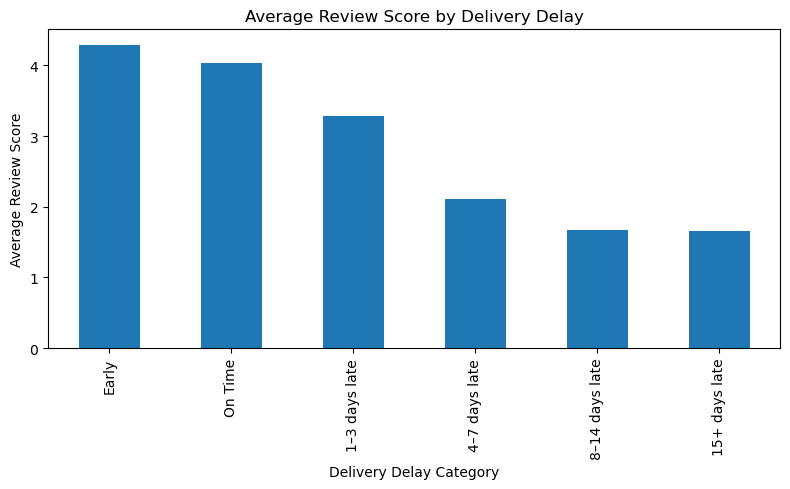

In [38]:
os.makedirs("../images", exist_ok=True)
delay_reviews = df.groupby("delay_group")["review_score"].mean()
plt.figure(figsize=(8,5))
delay_reviews.plot(kind="bar")
plt.title("Average Review Score by Delivery Delay")
plt.xlabel("Delivery Delay Category")
plt.ylabel("Average Review Score")
plt.tight_layout()
plt.savefig("../images/delay_vs_review.png")
plt.show()

In [39]:
# Customer Location Analysis

In [40]:
customers_small = customers[["customer_id", "customer_state"]]

df = df.merge(
    customers_small,
    on="customer_id",
    how="left"
)

In [41]:
# Late Delivery Rate by State

In [42]:
late_by_state = (
    df.groupby("customer_state")["is_late"]
    .mean()
    .sort_values(ascending=False)
)

late_by_state.head(10)

customer_state
AL    0.214464
MA    0.173370
SE    0.152239
PI    0.138365
CE    0.138066
BA    0.122212
RR    0.121951
RJ    0.121014
PA    0.111345
ES    0.106786
Name: is_late, dtype: float64

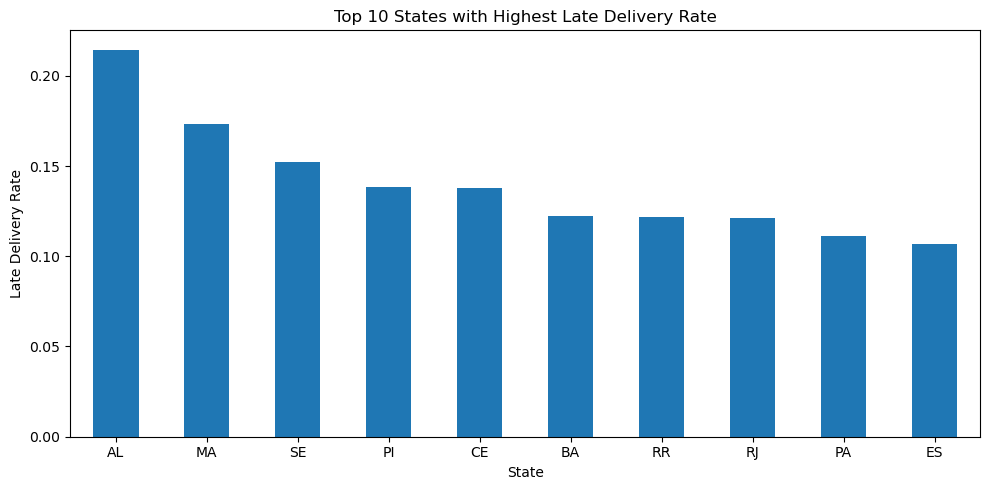

In [43]:
os.makedirs("../images", exist_ok=True)
plt.figure(figsize=(10,5))
late_by_state.head(10).plot(kind="bar")
plt.title("Top 10 States with Highest Late Delivery Rate")
plt.xlabel("State")
plt.ylabel("Late Delivery Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../images/late_by_state.png")
plt.show()

In [44]:
# Product Category Analysis

In [45]:
items_small = items[["order_id", "product_id"]]

df = df.merge(
    items_small,
    on="order_id",
    how="left"
)

products_small = products[["product_id", "product_category_name"]]

df = df.merge(
    products_small,
    on="product_id",
    how="left"
)

In [46]:
# Late Delivery by Category
late_by_category = (
    df.groupby("product_category_name")["is_late"]
    .mean()
    .sort_values(ascending=False)
)

late_by_category.head(10)

product_category_name
moveis_colchao_e_estofado         0.135135
casa_conforto_2                   0.133333
audio                             0.115702
artigos_de_natal                  0.100000
fashion_underwear_e_moda_praia    0.094488
casa_conforto                     0.092593
moveis_escritorio                 0.079857
livros_tecnicos                   0.079245
bebes                             0.076589
eletronicos                       0.075824
Name: is_late, dtype: float64

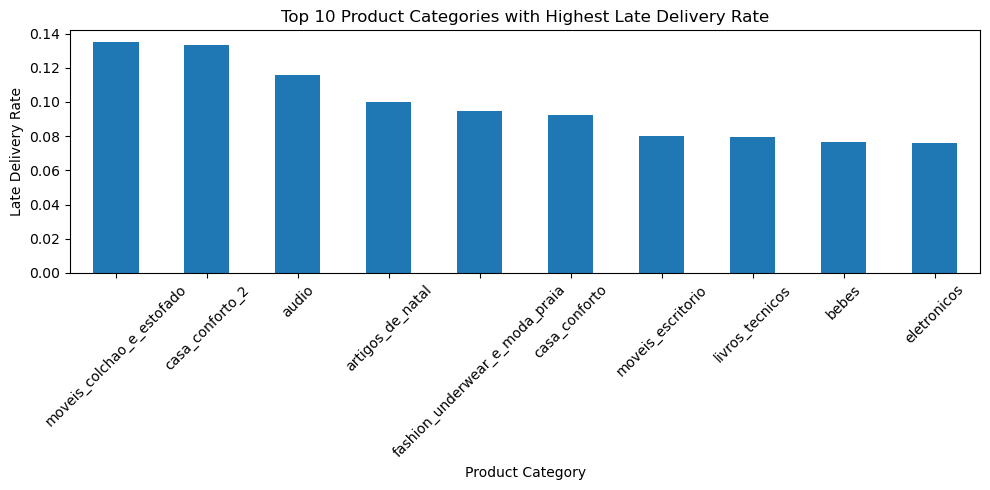

In [47]:
os.makedirs("../images", exist_ok=True)
plt.figure(figsize=(10,5))
late_by_category.head(10).plot(kind="bar")
plt.title("Top 10 Product Categories with Highest Late Delivery Rate")
plt.xlabel("Product Category")
plt.ylabel("Late Delivery Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/category_delay.png")
plt.show()

In [48]:
# Seller Performance Analysis

In [49]:
items_small = items[["order_id", "seller_id"]]

df = df.merge(
    items_small,
    on="order_id",
    how="left"
)

In [50]:
# Late Delivery Rate by Seller
seller_delay = (
    df.groupby("seller_id")["is_late"]
    .mean()
    .sort_values(ascending=False)
)

In [51]:
# Filter out sellers with a small number of orders
seller_stats = (
    df.groupby("seller_id")
    .agg(
        orders=("order_id", "count"),
        late_rate=("is_late", "mean")
    )
)

seller_stats = seller_stats[seller_stats["orders"] > 50]

seller_stats = seller_stats.sort_values("late_rate", ascending=False)

In [52]:
# Top sellers with delays
seller_stats.head(10)

,orders,late_rate
seller_id,,
2709af9587499e95e803a6498a5a56e9,469,0.944563
0d85bbda9889ce1f7e63778d24f346eb,92,0.445652
56642bcb79900e777d68e91915cb4267,92,0.423913
bbad7e518d7af88a0897397ffdca1979,157,0.388535
6039e27294dc75811c0d8a39069f52c0,130,0.353846
54965bbe3e4f07ae045b90b0b8541f52,102,0.352941
2a1348e9addc1af5aaa619b1a3679d6b,65,0.323077
ede0c03645598cdfc63ca8237acbe73d,57,0.298246
835f0f7810c76831d6c7d24c7a646d4d,65,0.292308


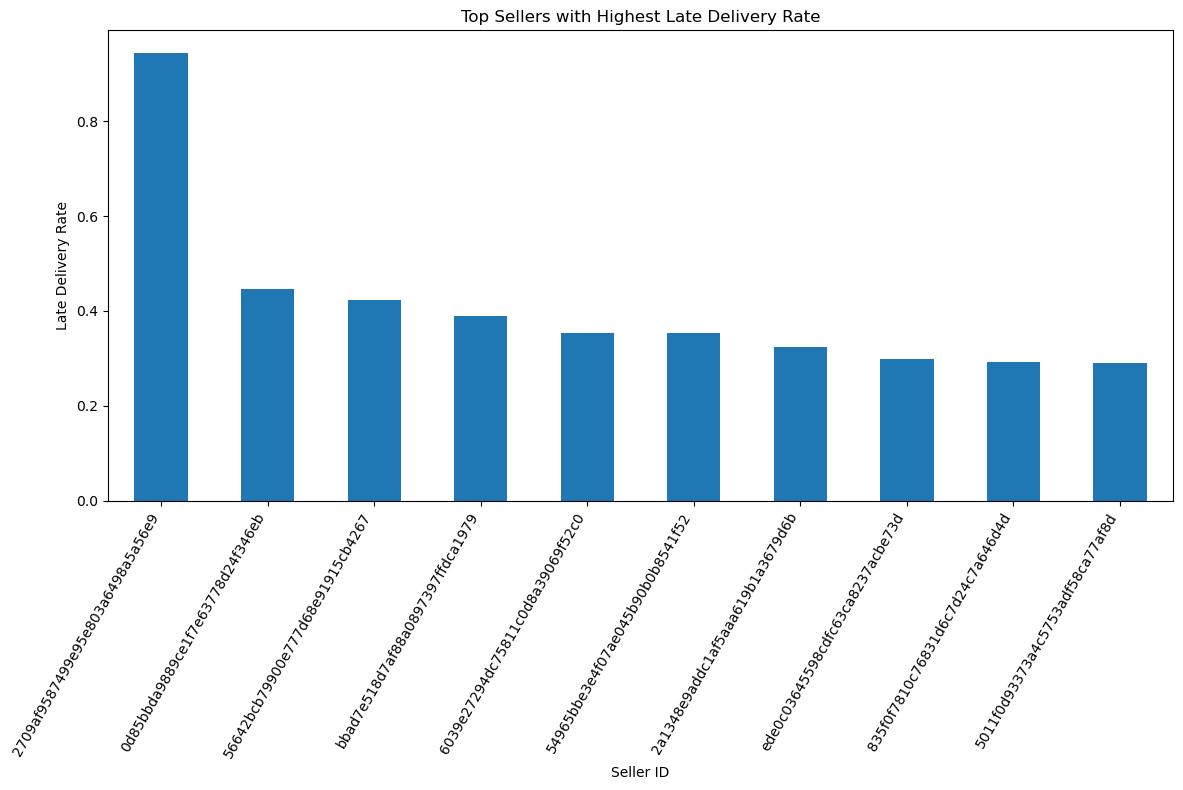

In [53]:
os.makedirs("../images", exist_ok=True)
top_sellers = seller_stats.sort_values("late_rate", ascending=False).head(10)
plt.figure(figsize=(12,8))
top_sellers["late_rate"].plot(kind="bar")
plt.title("Top Sellers with Highest Late Delivery Rate")
plt.xlabel("Seller ID")
plt.ylabel("Late Delivery Rate")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.savefig("../images/seller_delay.png", dpi=300)
plt.show()

In [54]:
# Delivery Performance Over Time

In [55]:
# Create a column for the month of order
df["order_month"] = df["order_purchase_timestamp"].dt.to_period("M")

In [56]:
# Calculate the proportion of late arrivals by month
late_by_month = (
    df.groupby("order_month")["is_late"]
    .mean()
)

In [57]:
# Convert the index back to a date (for the chart)
late_by_month.index = late_by_month.index.to_timestamp()

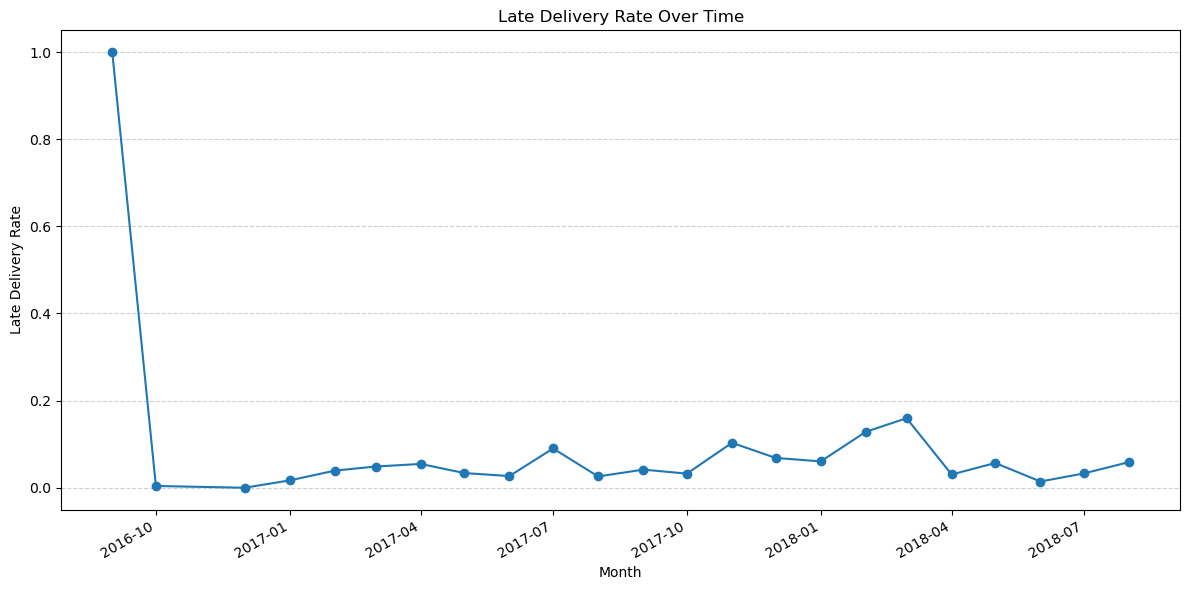

In [58]:
os.makedirs("../images", exist_ok=True)
plt.figure(figsize=(12,6))
late_by_month.plot(marker="o")
plt.title("Late Delivery Rate Over Time")
plt.xlabel("Month")
plt.ylabel("Late Delivery Rate")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("../images/late_delivery_over_time.png", dpi=300)
plt.show()

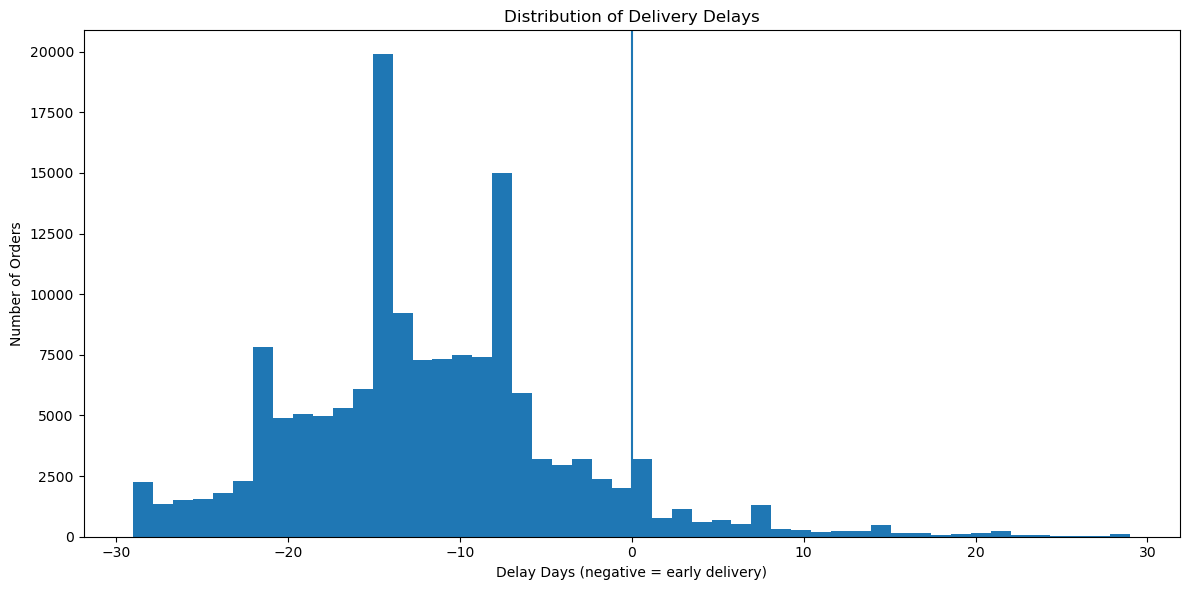

In [59]:
os.makedirs("../images", exist_ok=True)
filtered = df[(df["delay_days"] > -30) & (df["delay_days"] < 30)]
plt.figure(figsize=(12,6))
plt.hist(filtered["delay_days"], bins=50)
plt.axvline(0)
plt.title("Distribution of Delivery Delays")
plt.xlabel("Delay Days (negative = early delivery)")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.savefig("../images/delay_distribution.png", dpi=300)
plt.show()

In [60]:
# Executive Summary

# This analysis investigated delivery performance and its impact on customer satisfaction in the Olist Brazilian e-commerce dataset.

# Key findings include:

# A measurable share of orders are delivered later than the estimated delivery date.
# Delivery delays significantly reduce customer review scores, indicating that logistics performance strongly affects customer satisfaction.
# Some geographic regions show higher late delivery rates, suggesting potential logistical inefficiencies.
# Certain product categories are associated with higher delivery delays, possibly due to product size or shipping complexity.
# A subset of sellers contributes disproportionately to late deliveries.

#These insights suggest that improving logistics planning, monitoring seller performance, and optimizing delivery processes could significantly improve customer satisfaction.